In [1]:
import pandas as pd
import numpy as np
import optuna
import os 
from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# Importing the FD002 Data from DataTxt

base_columns = ['unit number', 'time, in cycles', 'operational setting 1', 'operational setting 2', 'operational setting 3']
sensor_columns = [f"sensor_{i}" for i in range(1, 22)]
all_columns = base_columns + sensor_columns

outputFolder = "DataParquet"
if not os.path.exists(outputFolder):
    os.mkdir(outputFolder)
    print(f"DataParquet, folder has been created")
    
df_raw = pd.read_csv("DataTxt/train_FD002.txt", sep=r"\s+", header=None, names=all_columns)
df_raw.to_parquet(f"{outputFolder}/raw_FD002_train.parquet", index=False)
print("Raw Data successfully loaded and frozen into a parquet file")

df_test = pd.read_csv("DataTxt/test_FD002.txt", sep=r"\s+", header=None, names=all_columns)
df_test.to_parquet(f"{outputFolder}/raw_FD002_test.parquet", index=False)
df_rul_answers = pd.read_csv("DataTxt/RUL_FD002.txt", header=None, names=["Remaining Life"]) ### HEY YOU, HERE IS YOUR ANSWERS
print("Raw Test Data successfully loaded and frozen into a parquet file.")

Raw Data successfully loaded and frozen into a parquet file
Raw Test Data successfully loaded and frozen into a parquet file.


In [3]:
print(df_raw[sensor_columns].std())

sensor_1      26.389707
sensor_2      37.289399
sensor_3     105.946341
sensor_4     119.123428
sensor_5       3.613839
sensor_6       5.431802
sensor_7     146.005306
sensor_8     145.209816
sensor_9     335.812013
sensor_10      0.127469
sensor_11      3.232372
sensor_12    137.659507
sensor_13    128.068271
sensor_14     84.837950
sensor_15      0.749335
sensor_16      0.004711
sensor_17     27.754515
sensor_18    145.327980
sensor_19      5.364067
sensor_20      9.869331
sensor_21      5.921615
dtype: float64


In [4]:
# here we will make a function for loading the parquet file
df_train_untrimmed = pd.read_parquet("DataParquet/raw_FD002_train.parquet")
df_test_untrimmed = pd.read_parquet("DataParquet/raw_FD002_test.parquet")

cols_to_drop = ['sensor_10', 'sensor_15', 'sensor_16']
df_train = df_train_untrimmed.drop(columns=(cols_to_drop)) # Train DF
df_test = df_test_untrimmed.drop(columns=(cols_to_drop)) # TEST DF

In [5]:
df_train.head(15)

,unit number,"time, in cycles",operational setting 1,operational setting 2,operational setting 3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,8341.91,42.02,183.06,2387.72,8048.56,334,2223,100.00,14.73,8.8071
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,8303.96,42.20,130.42,2387.66,8072.30,330,2212,100.00,10.41,6.2665
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,8001.42,36.69,164.22,2028.03,7864.87,309,1915,84.93,14.08,8.6723
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,8303.96,41.96,130.72,2387.61,8068.66,329,2212,100.00,10.59,6.4701
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,7993.23,36.89,164.31,2028.00,7861.23,309,1915,84.93,14.13,8.5286
5,1,6,25.0045,0.6205,60.0,462.54,537.02,1266.38,1048.72,7.05,...,7996.10,36.78,164.27,2028.01,7868.87,306,1915,84.93,14.28,8.5590
6,1,7,42.0043,0.8409,100.0,445.00,549.74,1347.45,1127.19,3.91,...,8307.75,42.19,130.49,2387.69,8075.54,330,2212,100.00,10.62,6.4227
7,1,8,20.0020,0.7002,100.0,491.19,607.44,1481.69,1252.36,9.35,...,8709.12,44.27,315.11,2387.99,8049.26,365,2324,100.00,24.33,14.7989
8,1,9,41.9995,0.8407,100.0,445.00,549.33,1348.23,1127.45,3.91,...,8312.33,42.30,130.97,2387.62,8065.78,331,2212,100.00,10.69,6.3802
9,1,10,42.0011,0.8400,100.0,445.00,549.33,1356.40,1127.11,3.91,...,8302.31,42.02,130.50,2387.62,8069.11,329,2212,100.00,10.57,6.2847


In [6]:
# Creation of the RUL (Validation) for the training set ------ OBTAINING THE TARGET VALUE ---------

# Groupby unit number while looking at time, in cycles
df_train['max_cycle_temp'] = df_train.groupby(['unit number'])['time, in cycles'].transform('max')
df_train['True_RUL'] = df_train['max_cycle_temp'] - df_train['time, in cycles']

df_train['Piecewise_RUL'] = df_train['True_RUL'].clip(upper=125)
df_train = df_train.drop(columns=(['max_cycle_temp', 'True_RUL']))
df_train.reset_index(drop=True, inplace=True)

df_train.head()

,unit number,"time, in cycles",operational setting 1,operational setting 2,operational setting 3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_11,sensor_12,sensor_13,sensor_14,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,Piecewise_RUL
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,42.02,183.06,2387.72,8048.56,334,2223,100.00,14.73,8.8071,125
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,42.20,130.42,2387.66,8072.30,330,2212,100.00,10.41,6.2665,125
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,36.69,164.22,2028.03,7864.87,309,1915,84.93,14.08,8.6723,125
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,41.96,130.72,2387.61,8068.66,329,2212,100.00,10.59,6.4701,125
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,36.89,164.31,2028.00,7861.23,309,1915,84.93,14.13,8.5286,125


In [7]:
# Time to check the correlation map for each column against PieceWise RUL 
# Plan is not to only rely on this but this will help for running ROlling avg / shift etc.

# Formulas:
# Thetta = T(Ambient) / 518.67
# Del = P(ambeint) / 14.696

# -- these are rankine values and psia values which is basically equivalent to that of kelvin and atm just within imperial system -- America

# Fan Speed Correction = N(raw) / Root(Thetta)
# Corrected Gas Temp = T(raw) / Thetta
# corrected pressure = P(raw) / Del
# Mass Flow Rate (Bleed) = ( W * Root(Thetta)) / Del

# Temperature Sensors --> 2,3,4,11
# Fan Speed sensors --> 8, 12, 13, 17
# Pressure sensors --> 7, 14
# Mass Flow Rate --> 20, 21

In [8]:
def preprocess_data(input_df: pd.DataFrame):
    copy_df = input_df.copy()
    # Making the functions
    copy_df['Theta'] = copy_df['sensor_1'] / 518.67
    copy_df['Delta'] = copy_df['sensor_5'] / 14.696
    
    # Applying
    temperature_cols = ['sensor_2', 'sensor_3', 'sensor_4']
    pressure_cols = ['sensor_7', 'sensor_6', 'sensor_11']
    speed_cols = ['sensor_8', 'sensor_9', 'sensor_13', 'sensor_14'] 
    mass_flow_rate_cols = ['sensor_20', 'sensor_21']
    
    copy_df[temperature_cols] = copy_df[temperature_cols].div(copy_df['Theta'], axis=0)
    copy_df[speed_cols] = copy_df[speed_cols].div(np.sqrt(copy_df['Theta']), axis=0)
    copy_df[pressure_cols] = copy_df[pressure_cols].div(copy_df['Delta'], axis=0)
    
    flow_multiplier = np.sqrt(copy_df['Theta']) / copy_df['Delta']
    copy_df[mass_flow_rate_cols] = copy_df[mass_flow_rate_cols].mul(flow_multiplier, axis=0)
    
    final_df = copy_df.drop(columns=['sensor_1', 'sensor_5', 'Theta', 'Delta'])
    print("Thermodynamic Normalization Complete")
    
    return final_df

df_train = preprocess_data(df_train)
df_test = preprocess_data(df_test)

df_train.head(10)

Thermodynamic Normalization Complete
Thermodynamic Normalization Complete


,unit number,"time, in cycles",operational setting 1,operational setting 2,operational setting 3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,sensor_11,sensor_12,sensor_13,sensor_14,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,Piecewise_RUL
0,1,1,34.9983,0.8400,100.0,640.859346,1567.885032,1312.404513,21.454015,521.976175,...,112.687212,183.06,2565.033850,8646.252008,334,2223,100.00,36.771524,21.985777,125
1,1,2,41.9982,0.8408,100.0,640.936254,1577.246331,1312.153511,21.461422,520.599223,...,158.611560,130.42,2577.733662,8714.908922,330,2212,100.00,36.241616,21.816339,125
2,1,3,24.9988,0.6218,60.0,602.513464,1409.269921,1174.559803,18.802542,366.274349,...,76.481736,164.22,2147.559927,8328.417057,309,1915,84.93,27.716716,17.071568,125
3,1,4,42.0077,0.8416,100.0,640.481689,1578.190427,1312.852842,21.461422,520.411294,...,157.709504,130.72,2577.679681,8710.979154,329,2212,100.00,36.868272,22.525157,125
4,1,5,25.0005,0.6203,60.0,602.244340,1410.335205,1175.098052,18.823387,364.898553,...,76.898644,164.31,2147.528159,8324.562520,309,1915,84.93,27.815141,16.788692,125
5,1,6,25.0045,0.6205,60.0,602.188272,1420.057324,1175.983920,18.823387,365.148698,...,76.669345,164.27,2147.538748,8332.652813,306,1915,84.93,28.110419,16.848535,125
6,1,7,42.0043,0.8409,100.0,640.749766,1570.521104,1313.796938,21.461422,521.350936,...,158.573974,130.49,2577.766050,8718.406847,330,2212,100.00,36.972715,22.360137,125
7,1,8,20.0020,0.7002,100.0,641.423695,1564.584280,1322.424237,21.454588,525.613835,...,69.582024,315.11,2453.879938,8271.356928,365,2324,100.00,37.214213,22.635816,125
8,1,9,41.9995,0.8407,100.0,640.271890,1571.430234,1314.099981,21.461422,518.907867,...,158.987417,130.97,2577.690477,8707.869886,331,2212,100.00,37.216415,22.212177,125
9,1,10,42.0011,0.8400,100.0,640.271890,1580.952782,1313.703694,21.461422,521.313350,...,157.935018,130.50,2577.690477,8711.464977,329,2212,100.00,36.798644,21.879701,125


In [9]:
def apply_regimes_and_scale(df_train, df_test):
    # 1. Define columns (Same as before)
    sensor_cols = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_6', 'sensor_11', 
                   'sensor_8', 'sensor_9', 'sensor_13', 'sensor_14', 'sensor_20', 'sensor_21']
    ops_cols = ['operational setting 1', 'operational setting 2', 'operational setting 3']

    # 2. Find regimes (Same as before)
    cluster_model = KMeans(n_clusters=6, random_state=42, n_init=10)
    df_train['regime_id'] = cluster_model.fit_predict(df_train[ops_cols])
    df_test['regime_id'] = cluster_model.predict(df_test[ops_cols])
    
    # 3. CRUCIAL FIX: Calculate means and std devs from TRAIN ONLY
    train_means = df_train.groupby('regime_id')[sensor_cols].mean()
    train_stds = df_train.groupby('regime_id')[sensor_cols].std()
    
    train_means_aligned = train_means.loc[df_train['regime_id']].values
    train_stds_aligned = train_stds.loc[df_train['regime_id']].values
    
    test_means_aligned = train_means.loc[df_test['regime_id']].values
    test_stds_aligned = train_stds.loc[df_test['regime_id']].values

    # 4. Perform the standardization ONLY on the sensor columns
    df_train[sensor_cols] = (df_train[sensor_cols] - train_means_aligned) / train_stds_aligned
    df_test[sensor_cols] = (df_test[sensor_cols] - test_means_aligned) / test_stds_aligned
            
    return df_train, df_test

df_train, df_test = apply_regimes_and_scale(df_train, df_test)

In [10]:
# Correlation map in order to see which ones correlate inversely and directly in a strong way
def correlation(input_df: pd.DataFrame):
    columns_to_check = [col for col in input_df.columns if 'sensor' in col] + ['Piecewise_RUL']
    correlation_matrix = input_df[columns_to_check].corr()
    
    target_correlations = correlation_matrix['Piecewise_RUL'].sort_values()
    
    print(target_correlations)
    
    return

correlation(df_train)

sensor_11       -0.770679
sensor_4        -0.737635
sensor_2        -0.630409
sensor_3        -0.618035
sensor_13       -0.476411
sensor_8        -0.475319
sensor_9        -0.422450
sensor_6        -0.362654
sensor_14       -0.321572
sensor_17       -0.032691
sensor_18        0.001563
sensor_12        0.001897
sensor_19        0.002180
sensor_21        0.479197
sensor_20        0.483756
sensor_7         0.509541
Piecewise_RUL    1.000000
Name: Piecewise_RUL, dtype: float64


In [11]:
def feature_dev(input_df: pd.DataFrame, is_training =True, train_min=None, train_max=None) -> pd.DataFrame:
    feature_df = input_df.copy()
    
    cols_to_keep = ['sensor_11', 'sensor_4', 'sensor_3', 'sensor_2', 'sensor_7' , 'sensor_20', 'sensor_21']
    for colname in cols_to_keep:
        mean_5_col = f"{colname}_roll_5_mean"
        mean_20_col = f"{colname}_roll_20_mean"
        divergence = f"{colname}_divergence"
        trend_acc = f"{colname}_trend_acc"
        systemic_volatility = f"{colname}_systemic_volatility"
        
        # General Feature Engineering
        
        feature_df[mean_5_col] = feature_df.groupby(['unit number'])[colname].transform(lambda x: x.rolling(window=5).mean())
        feature_df[mean_20_col] = feature_df.groupby(['unit number'])[colname].transform(lambda x: x.rolling(window=20).mean())
        feature_df[divergence] = feature_df[mean_20_col] - feature_df[mean_5_col]
        feature_df[trend_acc] = feature_df.groupby(['unit number'])[colname].diff(periods=5)
        feature_df[systemic_volatility] = feature_df.groupby(['unit number'])[colname].transform(lambda x: x.rolling(window=5).std())
    
    feature_df['cross_sensor_ratio'] = feature_df['sensor_11'] / feature_df['sensor_7']
    
    # Health Index
    corr_dict = {
        "sensor_11":0.77,
        "sensor_4":0.73,
        "sensor_3":0.61,
        "sensor_2":0.63,
        "sensor_7":0.50,
        "sensor_20":0.48,
        "sensor_21":0.47
    }
    
    total_corr = sum(corr_dict.values())
    
    # Weight distribution
    weights = {sensor: score / total_corr for sensor, score in corr_dict.items()}
    
    feature_df['Raw_Health'] = 0.0
    for sensor, weight in weights.items():
        if sensor in ['sensor_11', 'sensor_4', 'sensor_3', 'sensor_2']:
            feature_df['Raw_Health'] += -1 * weight * feature_df[sensor]
        
        else:
            feature_df['Raw_Health'] += weight * feature_df[sensor]
            
    if is_training:      
        train_max = feature_df['Raw_Health'].max()
        train_min = feature_df['Raw_Health'].min()
        
        feature_df['Health_Index'] = (feature_df['Raw_Health'] - train_min) / (train_max - train_min)

    else:        
        feature_df['Health_Index'] = (feature_df['Raw_Health'] - train_min) / (train_max - train_min)
        feature_df['Health_Index'] = feature_df['Health_Index'].clip(lower=0.0, upper=1.0)
        
    feature_df = feature_df.drop(columns=['Raw_Health'])
    
    # Cleaning the DataFrame - Take any Roll_20_avg
    feature_df = feature_df.dropna(subset=['sensor_11_roll_20_mean'])
    feature_df = feature_df.reset_index(drop=True)
    
    
    if is_training:
        return feature_df, train_min, train_max
    else:
        return feature_df

df_train, global_min, global_max = feature_dev(df_train, True)
df_test = feature_dev(df_test, False, global_min, global_max)

In [12]:
df_train.info()
df_train.head()

<class 'pandas.DataFrame'>
RangeIndex: 48819 entries, 0 to 48818
Data columns (total 60 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   unit number                    48819 non-null  int64  
 1   time, in cycles                48819 non-null  int64  
 2   operational setting 1          48819 non-null  float64
 3   operational setting 2          48819 non-null  float64
 4   operational setting 3          48819 non-null  float64
 5   sensor_2                       48819 non-null  float64
 6   sensor_3                       48819 non-null  float64
 7   sensor_4                       48819 non-null  float64
 8   sensor_6                       48819 non-null  float64
 9   sensor_7                       48819 non-null  float64
 10  sensor_8                       48819 non-null  float64
 11  sensor_9                       48819 non-null  float64
 12  sensor_11                      48819 non-null  float64
 1

,unit number,"time, in cycles",operational setting 1,operational setting 2,operational setting 3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,sensor_20_divergence,sensor_20_trend_acc,sensor_20_systemic_volatility,sensor_21_roll_5_mean,sensor_21_roll_20_mean,sensor_21_divergence,sensor_21_trend_acc,sensor_21_systemic_volatility,cross_sensor_ratio,Health_Index
0,1,20,20.0020,0.7015,100.0,0.723698,-0.544253,0.337644,0.713276,-0.110080,...,-0.184501,-0.052227,1.326923,0.632783,0.281806,-0.350978,-0.292303,0.496982,0.694203,0.571900
1,1,21,42.0028,0.8403,100.0,-0.057482,-0.740753,0.321788,0.844025,-1.594948,...,0.125093,-1.386581,1.162141,0.639498,0.385872,-0.253626,0.033574,0.498266,-0.344524,0.556046
2,1,22,42.0043,0.8419,100.0,-0.288509,-0.307630,0.213107,-1.184711,0.363491,...,-0.128347,1.661009,0.841131,0.759813,0.508208,-0.251605,0.601575,0.536273,-1.598904,0.659010
3,1,23,41.9987,0.8416,100.0,-0.611947,-1.241330,-0.196738,-1.184711,-0.183050,...,0.271305,-1.651642,0.364599,0.799243,0.483949,-0.315294,0.197148,0.568144,4.090116,0.702797
4,1,24,42.0011,0.8400,100.0,1.097652,-0.291654,0.015386,0.844025,-0.957317,...,0.238874,-0.092660,0.403824,0.613877,0.398330,-0.215547,-0.926831,0.611447,0.519612,0.541794


In [13]:
# Making the test set 
# According to Nasa CMAPSS, the RUL Answers are provided based on teh very last cycle it was run at which means you cannot feed all the cycles present for each unit 
# from the test data set

X_test = df_test.groupby('unit number').last().reset_index()

cols_to_drop = ['unit number', 'time, in cycles']
X_test_clean = X_test.drop(columns=[col for col in cols_to_drop if col in X_test.columns])

y_test = df_rul_answers['Remaining Life']

In [14]:
def error_detection(y_true, y_pred):
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    d = y_pred - y_true
    penalties = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    
    total_score = np.sum(penalties)
    
    print(f"Validation Size: {len(d)} rows")
    print(f"Sum of Early Preds: {np.sum(d<=0)}")
    print(f"Sum of Late Preds: {np.sum(d>0)}")
    
    return total_score

In [15]:
import sqlite3

def log_flight_model_run(dataset_id, architecture, params, val_score, test_score=None):
    """Used for logging experiment results"""
    with sqlite3.connect('nasa_cmapss_logs.db') as conn:
        cursor = conn.cursor()
        
        query = ("""
                       INSERT OR IGNORE INTO flight_model_runs (
                           dataset_id, model_architecture, learning_rate, max_depth, n_estimators, subsample,
                           colsample_bytree, min_child_weight, reg_alpha, reg_lambda,
                           val_score, test_nasa_score
                       ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
                       """)
        
        values = (
            dataset_id, architecture, 
            params.get('learning_rate'), params.get('max_depth'), params.get('n_estimators'),
            params.get('subsample'), params.get('colsample_bytree'), params.get('min_child_weight'),
            params.get('reg_alpha'), params.get('reg_lambda'),
            val_score, test_score
        )
        
        cursor.execute(query, values)
        conn.commit()

In [16]:

def split_data(input_df: pd.DataFrame):
    final_df = input_df.copy()
    
    columns_to_drop = ['unit number', 'time, in cycles', 'Piecewise_RUL']
    val_range = list(range(81, 101))
    df_val_set = final_df[final_df['unit number'].isin(val_range)]
    df_train_set = final_df[~final_df['unit number'].isin(val_range)]
    
    train_groups = df_train_set['unit number']
    
    X_train = df_train_set.drop(columns=columns_to_drop)
    y_train = df_train_set['Piecewise_RUL']
    
    X_val = df_val_set.drop(columns=columns_to_drop)
    y_val = df_val_set['Piecewise_RUL']
    
    return X_train, y_train, X_val, y_val, train_groups

X_train, y_train, X_val, y_val, train_groups = split_data(df_train)

In [17]:
def nasa_objective(y_true, y_pred):
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    d = y_pred - y_true
    
    grad = np.zeros_like(d, dtype=float)
    hess = np.zeros_like(d, dtype=float)
    
    early = d < 0 
    grad[early] = -1/13 * np.exp(-d[early] / 13)
    hess[early] = 1/169 * np.exp(-d[early] / 13)
    
    late = d >= 0 
    grad[late] = 1/10 * np.exp(d[late] / 10)
    hess[late] = 1/100 * np.exp(d[late] / 10)
    
    return grad, hess

In [18]:
def train_model(X_train, y_train, X_val, y_val) -> tuple[XGBRegressor, float]:
    # Baseline
    model = XGBRegressor(
        random_state=42,
        n_estimators=100,
        learning_rate=0.1,
        objective=nasa_objective,
        max_depth=5
    )
    
    model.fit(X_train, y_train)
    
    preds = model.predict(X_val)
    score = error_detection(y_val, preds)
    
    print(f"Error Score --> {score}")
    
    return model, score

train_engine, val_score = train_model(X_train, y_train, X_val, y_val)
baseline_params = train_engine.get_params()

test_preds_base = train_engine.predict(X_test_clean)
base_test_score = error_detection(y_test, test_preds_base)

# log_flight_model_run("FD002", "XGBoost", baseline_params, val_score, base_test_score)

Validation Size: 4045 rows
Sum of Early Preds: 2968
Sum of Late Preds: 1077
Error Score --> 27417.955247600737
Validation Size: 259 rows
Sum of Early Preds: 166
Sum of Late Preds: 93


## Optuna

We have ran our Baseline model and we noticed that our predictions usually go for the early ones which is perfectly fine. We now have to lower the late predictions further.


In [19]:
import optuna
from sklearn.model_selection import GroupKFold

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300, step=50),

        'max_depth': trial.suggest_int('max_depth', 3, 5), 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        
        # --- THE REGULARIZATION CHAINS ---
        # min_child_weight stops the tree from splitting if a leaf has too few samples
        'min_child_weight': trial.suggest_int('min_child_weight', 3, 10),
        # L1/L2 Regularization mathematically penalizes large leaf weights
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }
    
    gkf = GroupKFold(n_splits=5)
    score = []
    for train_idx, val_idx in gkf.split(X_train, y_train, groups=train_groups):
        X_tr_fold, X_va_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr_fold, y_va_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        opt_model = XGBRegressor(
            **params,
            objective=nasa_objective,
            random_state=42,
            n_jobs=-1,
            early_stopping_rounds=20
        )
        
        opt_model.fit(
            X_tr_fold, y_tr_fold,
            eval_set=[(X_va_fold, y_va_fold)],
            verbose=False
        )
        
        opt_preds = opt_model.predict(X_va_fold)
        opt_score = error_detection(y_va_fold, opt_preds)
        
        score.append(opt_score)
        
    return np.mean(score)

print("Initiating Optuna Study")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)

opt_xgb_best_model = XGBRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1,
    objective=nasa_objective
)

opt_xgb_best_model.fit(X_train,y_train)

test_opt_preds = opt_xgb_best_model.predict(X_test_clean)
test_opt_score = error_detection(y_test, test_opt_preds)
xgb_params = study.best_params

# log_flight_model_run("FD002", "XGBRegressor Optuna", study.best_params, study.best_value, test_opt_score)

[I 2026-06-21 20:24:34,230] A new study created in memory with name: no-name-1a621c21-c587-4f02-8fa8-1df2dd8bf9c8


Initiating Optuna Study
Validation Size: 8958 rows
Sum of Early Preds: 5959
Sum of Late Preds: 2999
Validation Size: 8956 rows
Sum of Early Preds: 5930
Sum of Late Preds: 3026
Validation Size: 8952 rows
Sum of Early Preds: 5510
Sum of Late Preds: 3442
Validation Size: 8956 rows
Sum of Early Preds: 5855
Sum of Late Preds: 3101


[I 2026-06-21 20:24:43,777] Trial 0 finished with value: 63076.52899067886 and parameters: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.03714429583858377, 'subsample': 0.8817469984090777, 'colsample_bytree': 0.7830109782276239, 'min_child_weight': 6, 'reg_alpha': 0.016835657770192445, 'reg_lambda': 0.006586990788688271}. Best is trial 0 with value: 63076.52899067886.


Validation Size: 8952 rows
Sum of Early Preds: 5696
Sum of Late Preds: 3256
Validation Size: 8958 rows
Sum of Early Preds: 7472
Sum of Late Preds: 1486
Validation Size: 8956 rows
Sum of Early Preds: 7492
Sum of Late Preds: 1464
Validation Size: 8952 rows
Sum of Early Preds: 7266
Sum of Late Preds: 1686
Validation Size: 8956 rows
Sum of Early Preds: 7467
Sum of Late Preds: 1489


[I 2026-06-21 20:24:51,086] Trial 1 finished with value: 1081354.798975265 and parameters: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.012868153362425394, 'subsample': 0.878365145009242, 'colsample_bytree': 0.8169358592307484, 'min_child_weight': 7, 'reg_alpha': 0.7440333719256597, 'reg_lambda': 0.6706426242201001}. Best is trial 0 with value: 63076.52899067886.


...

Validation Size: 8952 rows
Sum of Early Preds: 5751
Sum of Late Preds: 3201
Validation Size: 8958 rows
Sum of Early Preds: 6012
Sum of Late Preds: 2946
Validation Size: 8956 rows
Sum of Early Preds: 5946
Sum of Late Preds: 3010
Validation Size: 8952 rows
Sum of Early Preds: 5580
Sum of Late Preds: 3372
Validation Size: 8956 rows
Sum of Early Preds: 5792
Sum of Late Preds: 3164


[I 2026-06-21 20:27:56,582] Trial 28 finished with value: 62872.175671491736 and parameters: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.0754114941140964, 'subsample': 0.7714091740993472, 'colsample_bytree': 0.8263451850778528, 'min_child_weight': 7, 'reg_alpha': 1.2080989786908394, 'reg_lambda': 0.6546793796427895}. Best is trial 7 with value: 62681.52467939102.


Validation Size: 8952 rows
Sum of Early Preds: 5709
Sum of Late Preds: 3243
Validation Size: 8958 rows
Sum of Early Preds: 6351
Sum of Late Preds: 2607
Validation Size: 8956 rows
Sum of Early Preds: 6378
Sum of Late Preds: 2578
Validation Size: 8952 rows
Sum of Early Preds: 6011
Sum of Late Preds: 2941
Validation Size: 8956 rows
Sum of Early Preds: 6318
Sum of Late Preds: 2638


[I 2026-06-21 20:28:02,828] Trial 29 finished with value: 90286.31420523234 and parameters: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.034378063377691434, 'subsample': 0.7688311673434854, 'colsample_bytree': 0.8326935128202341, 'min_child_weight': 7, 'reg_alpha': 4.2374321311698235, 'reg_lambda': 0.06822659876175083}. Best is trial 7 with value: 62681.52467939102.


Validation Size: 8952 rows
Sum of Early Preds: 6140
Sum of Late Preds: 2812
Validation Size: 259 rows
Sum of Early Preds: 165
Sum of Late Preds: 94


In [20]:
import optuna
from lightgbm import LGBMRegressor, early_stopping
from sklearn.model_selection import GroupKFold
import numpy as np

def objective_lgbm(trial):
    # LightGBM-specific search space
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300, step=50),
        'num_leaves': trial.suggest_int('num_leaves', 20, 60), # Crucial for LGBM!
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }
    
    gkf = GroupKFold(n_splits=5)
    group_score = []
    
    for train_idx, val_idx in gkf.split(X_train, y_train, groups=train_groups):
        
        X_tr_fold = X_train.iloc[train_idx]
        y_tr_fold = y_train.iloc[train_idx]
        X_va_fold = X_train.iloc[val_idx]
        y_va_fold = y_train.iloc[val_idx]
        
        model_lgbm = LGBMRegressor (
            **params,
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )
        
        model_lgbm.fit(
            X_tr_fold, y_tr_fold,
            eval_set=[(X_va_fold, y_va_fold)],
            callbacks=[early_stopping(stopping_rounds=20, verbose=False)]
        )

        preds = model_lgbm.predict(X_va_fold)
        score = error_detection(y_va_fold, preds)
        group_score.append(score)

    return np.mean(group_score)

# Run the LightGBM Study
print("Running LightGBM Optuna Study...")
study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=30)

opt_lgbm_best_model = LGBMRegressor(
    **study_lgbm.best_params,
    random_state=42,
    verbosity=-1
).fit(X_train, y_train)
test_lgbm_opt_preds = opt_lgbm_best_model.predict(X_test_clean)
test_lgbm_opt_score = error_detection(y_test, test_lgbm_opt_preds)

# Save the params safely!
lgbm_params = study_lgbm.best_params
print("LightGBM Params Saved:", lgbm_params)

log_flight_model_run("FD002", "LGBMRegressor Optuna", lgbm_params, study_lgbm.best_value, test_lgbm_opt_score)

[I 2026-06-21 20:28:04,194] A new study created in memory with name: no-name-52317dd9-e575-4346-bb62-2289ec85ba10


Running LightGBM Optuna Study...
Validation Size: 8958 rows
Sum of Early Preds: 4708
Sum of Late Preds: 4250
Validation Size: 8956 rows
Sum of Early Preds: 4722
Sum of Late Preds: 4234
Validation Size: 8952 rows
Sum of Early Preds: 4404
Sum of Late Preds: 4548
Validation Size: 8956 rows
Sum of Early Preds: 4643
Sum of Late Preds: 4313


[I 2026-06-21 20:28:08,574] Trial 0 finished with value: 87021.87468551441 and parameters: {'n_estimators': 100, 'num_leaves': 41, 'max_depth': 6, 'learning_rate': 0.013485395736182942, 'subsample': 0.7465193922872165, 'colsample_bytree': 0.6226749163547949, 'reg_alpha': 0.02023340761652689, 'reg_lambda': 0.49782138253315883}. Best is trial 0 with value: 87021.87468551441.


Validation Size: 8952 rows
Sum of Early Preds: 4536
Sum of Late Preds: 4416
Validation Size: 8958 rows
Sum of Early Preds: 5048
Sum of Late Preds: 3910
Validation Size: 8956 rows
Sum of Early Preds: 4997
Sum of Late Preds: 3959
Validation Size: 8952 rows
Sum of Early Preds: 4582
Sum of Late Preds: 4370
Validation Size: 8956 rows
Sum of Early Preds: 4976
Sum of Late Preds: 3980


[I 2026-06-21 20:28:10,508] Trial 1 finished with value: 94213.03794903033 and parameters: {'n_estimators': 200, 'num_leaves': 42, 'max_depth': 3, 'learning_rate': 0.01706321642813627, 'subsample': 0.8288682761829043, 'colsample_bytree': 0.6352828446827092, 'reg_alpha': 0.9597876899780144, 'reg_lambda': 0.07191246406483413}. Best is trial 0 with value: 87021.87468551441.


...

Validation Size: 8952 rows
Sum of Early Preds: 4573
Sum of Late Preds: 4379
Validation Size: 8958 rows
Sum of Early Preds: 5172
Sum of Late Preds: 3786
Validation Size: 8956 rows
Sum of Early Preds: 5308
Sum of Late Preds: 3648
Validation Size: 8952 rows
Sum of Early Preds: 4811
Sum of Late Preds: 4141
Validation Size: 8956 rows
Sum of Early Preds: 5240
Sum of Late Preds: 3716


[I 2026-06-21 20:29:51,838] Trial 28 finished with value: 94544.78335518531 and parameters: {'n_estimators': 150, 'num_leaves': 28, 'max_depth': 6, 'learning_rate': 0.09470348553828817, 'subsample': 0.6520623001091563, 'colsample_bytree': 0.7962246665289466, 'reg_alpha': 0.0010027423101267535, 'reg_lambda': 0.027683889489605262}. Best is trial 5 with value: 83887.23870756612.


Validation Size: 8952 rows
Sum of Early Preds: 4993
Sum of Late Preds: 3959
Validation Size: 8958 rows
Sum of Early Preds: 5124
Sum of Late Preds: 3834
Validation Size: 8956 rows
Sum of Early Preds: 5184
Sum of Late Preds: 3772
Validation Size: 8952 rows
Sum of Early Preds: 4735
Sum of Late Preds: 4217
Validation Size: 8956 rows
Sum of Early Preds: 5152
Sum of Late Preds: 3804


[I 2026-06-21 20:29:57,400] Trial 29 finished with value: 93109.21058636476 and parameters: {'n_estimators': 250, 'num_leaves': 50, 'max_depth': 6, 'learning_rate': 0.0179978387038444, 'subsample': 0.6191117528242233, 'colsample_bytree': 0.7534780250698562, 'reg_alpha': 0.02616617360932722, 'reg_lambda': 0.3146805161904359}. Best is trial 5 with value: 83887.23870756612.


Validation Size: 8952 rows
Sum of Early Preds: 4879
Sum of Late Preds: 4073
Validation Size: 259 rows
Sum of Early Preds: 121
Sum of Late Preds: 138
LightGBM Params Saved: {'n_estimators': 150, 'num_leaves': 46, 'max_depth': 7, 'learning_rate': 0.011888310160797017, 'subsample': 0.6350250760927967, 'colsample_bytree': 0.6996961481610273, 'reg_alpha': 0.002006459494420615, 'reg_lambda': 1.7362593417377237}


## Analysis

From here we obtained a val_score of around 62,000 while a test score of around 20k (slightly lower than the base model)

Due to the minimal change, we will apply the usage of a multi-stacking model to finally check if we can improve it further.

Following which we will conclude via a Feature Importance chart to understand which factors played an important role.

In [21]:
from sklearn.linear_model import RidgeCV
from lightgbm import LGBMRegressor

def model_stack(input_x, input_y):
    xgb_oof = np.zeros(len(input_x))
    lgb_oof = np.zeros(len(input_x))
    
    gkf = GroupKFold(n_splits=5)
    for fold, (train_idx, val_idx) in enumerate(gkf.split(input_x, input_y, groups=train_groups)):
        X_tr_fold, X_va_fold = input_x.iloc[train_idx], input_x.iloc[val_idx]
        y_tr_fold, y_va_fold = input_y.iloc[train_idx], input_y.iloc[val_idx]
        
        model_xgb = XGBRegressor(
            random_state=42,
            objective=nasa_objective,
            n_jobs=-1,
        ).fit(X_tr_fold, y_tr_fold)
        
        model_lgb = LGBMRegressor(
            random_state=42,
            verbosity=-1
        ).fit(X_tr_fold, y_tr_fold)
    
        xgb_oof[val_idx] = model_xgb.predict(X_va_fold)
        lgb_oof[val_idx] = model_lgb.predict(X_va_fold)
    
    X_meta_train = pd.DataFrame({
        'XGB': xgb_oof,
        'LGB': lgb_oof
    })
    
    ridge_vals = [0.01, 0.1, 1.0, 10.0, 100.0]
    meta_model = RidgeCV(alphas=ridge_vals)
    meta_model.fit(X_meta_train, input_y)
    
    print(f"Optimal Alpha Selected: {meta_model.alpha_}")
    print(f"Ensemble Weights -> XGBoost: {meta_model.coef_[0]:.4f} | LightGBM: {meta_model.coef_[1]:.4f}")
    
    return meta_model

meta_model = model_stack(X_train, y_train)

Optimal Alpha Selected: 100.0
Ensemble Weights -> XGBoost: 0.2145 | LightGBM: 0.7848


In [23]:
# stacked model evaluation
full_xgb = XGBRegressor(
    **xgb_params,
    random_state=42,
    n_jobs=-1,
    objective=nasa_objective
).fit(X_train, y_train)

full_lgb = LGBMRegressor(
    **lgbm_params,
    verbosity=-1,
    random_state=42
).fit(X_train, y_train)

val_meta_xgb = full_xgb.predict(X_val)
val_meta_lgb = full_lgb.predict(X_val)
X_meta_val = pd.DataFrame({
    'XGB': val_meta_xgb,
    'LGB': val_meta_lgb
})

final_stacked_val = meta_model.predict(X_meta_val)
final_val_stacked_score = error_detection(y_val, final_stacked_val)

# Stacked model testing
test_meta_xgb = full_xgb.predict(X_test_clean)
test_meta_lgb = full_lgb.predict(X_test_clean)
X_meta_test = pd.DataFrame({
    'XGB': test_meta_xgb,
    'LGB': test_meta_lgb
})

stack_params = {
    'ridge_alpha': meta_model.alpha_,
    'xgb_weight': meta_model.coef_[0],
    'lgb_weight': meta_model.coef_[1]
}

y_test_stack = meta_model.predict(X_meta_test)
y_test_stack_score = error_detection(y_test, y_test_stack)

print(f"Score obtained from evaluation {final_val_stacked_score}")
print(f"Test Score: {y_test_stack_score}")

log_flight_model_run("FD002", "model stacking", stack_params, final_val_stacked_score, y_test_stack_score)

Validation Size: 4045 rows
Sum of Early Preds: 2441
Sum of Late Preds: 1604
Validation Size: 259 rows
Sum of Early Preds: 119
Sum of Late Preds: 140
Score obtained from evaluation 27290.492891686416
Test Score: 14342.685597500753


## Success 
For a strict ML tabular model creation, we have practically hit the limit.

What we did:
- Cleaned the data
- Grouped by Regime_id in order to have more correlation
- Engineered some more features 
- Took the last values of the test answers
- Trained model using baseline
- Trianed model using optuna XGB
- Trained model using Optuna LGBM
- Trained model using stack (LGBM + XGB) + (RidgeCV) using the best params from optuna xgb and lgbm

--- XGBoost Brain ---


/tmp/ipykernel_22151/1502429628.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(top_n), x="Importance", y="Feature", palette='viridis')


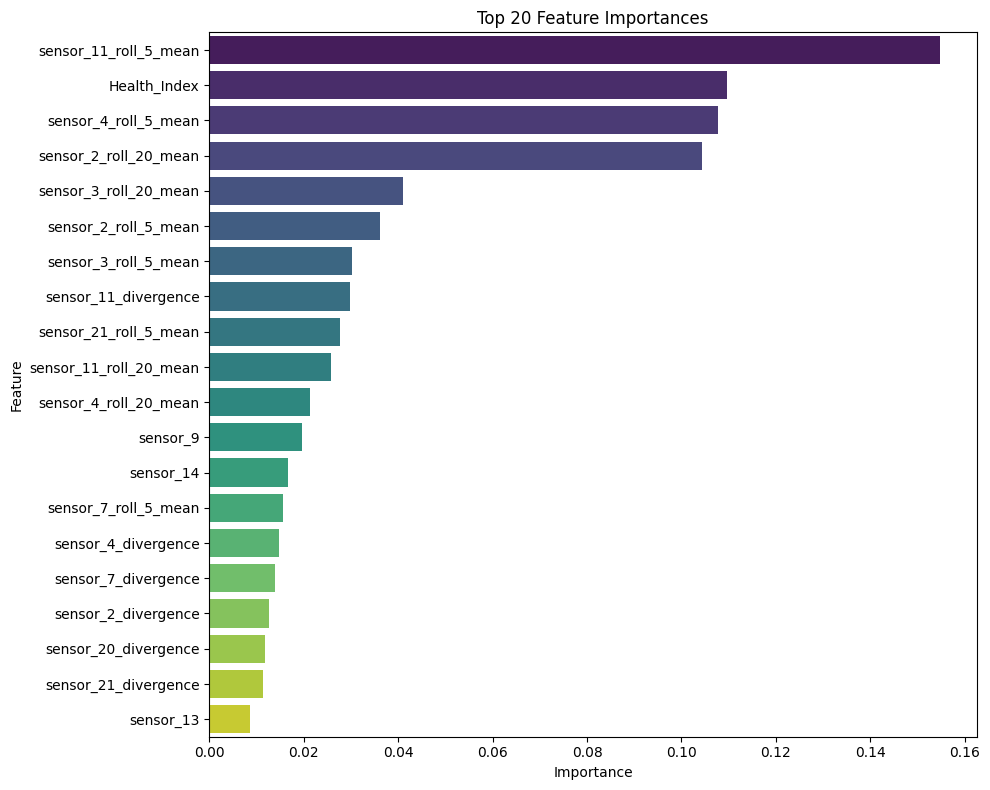

--- LightGBM Brain ---


/tmp/ipykernel_22151/1502429628.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(top_n), x="Importance", y="Feature", palette='viridis')


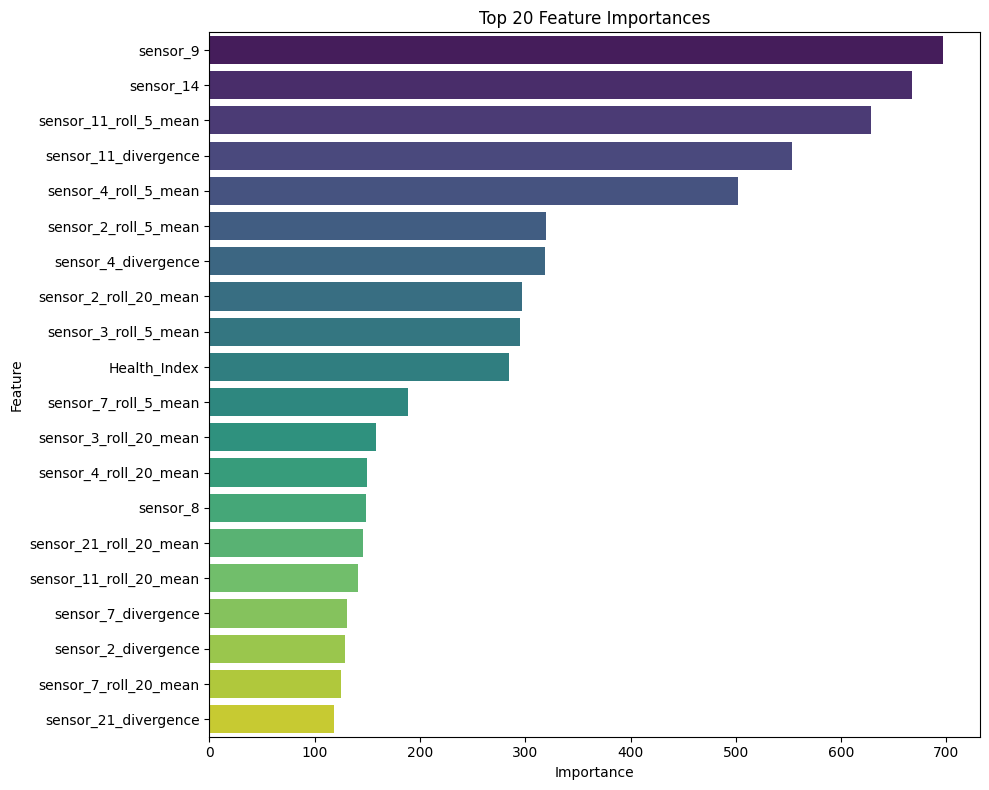

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importance(trained_model, feature_name, top_n=20):
    importance_df = pd.DataFrame({
        'Feature': feature_name,
        'Importance': trained_model.feature_importances_
    })
    
    importance_df = importance_df.sort_values(by='Importance', ascending=False)
    
    plt.figure(figsize=(10,8))
    sns.barplot(data=importance_df.head(top_n), x="Importance", y="Feature", palette='viridis')
    plt.title(f"Top {top_n} Feature Importances")
    plt.tight_layout()
    plt.show()
    
    return importance_df

print("--- XGBoost Brain ---")
xgb_importance = plot_feature_importance(full_xgb, X_train.columns)

print("--- LightGBM Brain ---")
lgbm_importance = plot_feature_importance(full_lgb, X_train.columns)

In [27]:
import joblib

fd002_artifact = {
    'lvl_0_xgb': full_xgb,
    'lvl_0_lgbm': full_lgb,
    'lvl_1_ridge': meta_model,
    'expected_features': list(X_train.columns)
}

outputFolder_model = "ModelFile"
if not os.path.exists(outputFolder_model):
    os.mkdir(outputFolder_model)
    print(f"ModelFile, folder has been created")

joblib.dump(fd002_artifact, f'{outputFolder_model}/FD002_champion_ensemble.joblib')
print(f"FD002 ensemble safely written to disk")

FD002 ensemble safely written to disk
